In [14]:
from qsopt import * 
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")
print(f"JAX backend: {jax.default_backend()}")
devices = jax.devices()
print(f"JAX devices: {devices}")
print(f"JAX GPU available: {any(d.platform == 'gpu' for d in devices)}")

JAX version: 0.9.2
QuTiP version: 5.2.2
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
JAX GPU available: True


## Define experimental parameters

In [15]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, -4.0, 0.0, 4.0, 8.0])/inverse_pulse_width),
    initial_time_uncertainty=2.0/inverse_pulse_width    
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.001,
    dephasing = 0.001,
    relaxation = 0.001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      5
  Measurement times:    [-8.0, -4.0, 0.0, 4.0, 8.0]
  Initial time uncertainty:   2.0000
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.001]
  Dephasing rate:       [0.001]
  Relaxation rate:      [0.001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


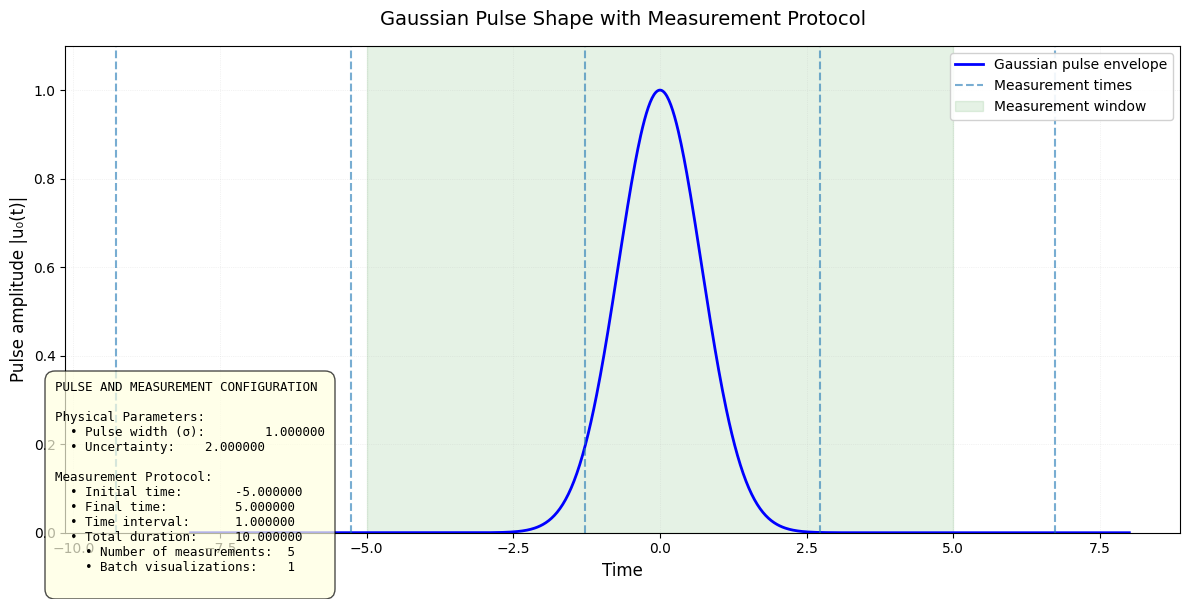

In [16]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The interface uses `QuantumCircuit` objects to define the gates applied before and after evolution.

In [17]:
from qsopt.core.circuit import create_ry_circuit
from qsopt.core.gates import RZGate
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
#initial_circuit.add_layer(RZGate, parameters=0.0)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.571)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.571)


## Define experiment

In [20]:
import math
somma = lambda x,y: x+y
identità = lambda x: x
softmax_max = lambda x,y: x + jnp.exp(y)
logaritmo = lambda x: jnp.log(x)
tan_h = lambda x: 1-(jnp.tanh(7*(x-0.5))+1)/2


detection_metric = DetectionMetric(n_qubits=1, 
                                   detection_criterion = 'max computational distance',
                                   metric = lambda x,y,f: -4*x*y + 1*tan_h(f)*(x**2 + y**2),
                                   multiple_measurement_logic = (0,softmax_max,logaritmo)
                                   )

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric:
maximize computational distance with custom metric
with custom measurement aggregation



## Test Single Simulation

In [21]:
results = experiment.run_simulation(debug=False, states_probabilities=True, measurement_times = [-8.0,3.0])
print(results)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.000000
     Metric:            -0.160220
  State Probabilities:
     With photon:
        0: 0.020702
        1: 0.979298
     Without photon:
        0: 0.979355
        1: 0.020645
  Detection Protocol:
     Interaction states: ['1']
     Non-interaction states: ['0']
  Confusion Matrix:
     --------------------
     True Positive:  0.979298
     False Negative: 0.020702
     --------------------
     True Negative:  0.979355
     False Positive: 0.020645
     --------------------


## Time Evolution

TimeEvolutionResults:
  Time interval: [-8, 8]
  Number of time points: 300
  System type: Single-qubit
  Detection Criterion: N/A
  Probabilities: ['detection_measure']
  Pulse shape: Available
  Measurement times: [-8.0, -4.0, 0.0, 4.0, 8.0]
  Cavity population: Available
  Field population: Available


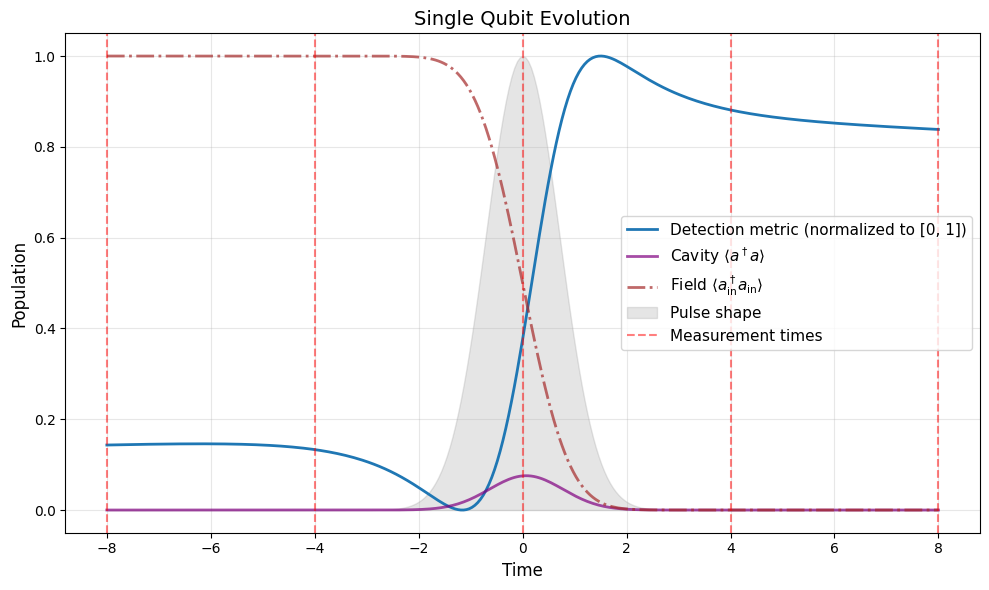

In [22]:
result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6),
    normalize_detection = True
)
plt.show()

## Run Optimization

In [ ]:
import optax

# Use an explicit callback so this history is not overwritten by later optimizations
history_callback = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[1, -0.8],# -2], 
    num_steps=2000,
    verbose=True,
    verbose_step=25,
    batch_size=100,
    tolerance=1e-7,
    callback=history_callback,
    optimizer=optax.sgd(learning_rate=0.1)
)

Configuration:
    Max iterations: 2000
    Batch size: 100
    Convergence tolerance: 1.00e-07
    Detection metric:
maximize computational distance with custom metric
with custom measurement aggregation
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.000  rad (57.3°)
        param1.  reset_RY[0]  = -0.800 rad (-45.8°)
    Measurement uncertainty: ±2.000
Step  setup0_RY[0]   reset0_RY[0]   Metric      Validation  Grad Norm   Time
---------------------------------------------------------------------------------


0     1.000000       -0.800000      0.931278    0.745325    2.85e-01    00h00m42s
1     1.021447       -0.818737      0.939075    0.747625    2.98e-01    00h00m42s
2     1.043654       -0.838653      0.964634    0.755076    3.63e-01    00h00m42s
25    1.543580       -1.495591      1.249989    0.831195    1.03e-01    00h00m48s
50    1.571305       -1.568820      1.350876    0.858874    3.63e-03    00h00m54s
75    1.570765       -1.571386      1.295095    0.843461    1.32e-04    00h01m00s
100   1.570669       -1.571552      1.311977    0.848093    1.54e-04    00h01m07s
125   1.570660       -1.571553      1.365636    0.863170    3.16e-04    00h01m13s
150   1.570665       -1.571534      1.230164    0.825902    1.39e-04    00h01m19s
175   1.570678       -1.571462      1.308409    0.847797    2.87e-05    00h01m25s
200   1.570674       -1.571524      1.307522    0.847377    1.10e-04    00h01m31s
225   1.570674       -1.571503      1.199151    0.817663    2.60e-04    00h01m37s
250   1.570671  

In [ ]:
print(history)

MODE: Optimization
     Total iterations: 2000
     Best epoch:        19
     Converged: False
     Final gradient norm: 1.396909e-04
  Best Parameters:
     Initial circuit:
        param_0: 1.474738 rad (84.50°)
     Final circuit:
        param_0: -1.377590 rad (-78.93°)
  Detection Measures:
     With photon:    0.000000
     Without photon: 0.000000
     Metric:            1.379764
  State Probabilities:
     With photon:
        0: 0.029793
        1: 0.970207
     Without photon:
        0: 0.970247
        1: 0.029753
  Detection Protocol:
     Interaction states: ['1']
     Non-interaction states: ['0']
  Confusion Matrix:
     --------------------
     True Positive:  0.970207
     False Negative: 0.029793
     --------------------
     True Negative:  0.970247
     False Positive: 0.029753
     --------------------


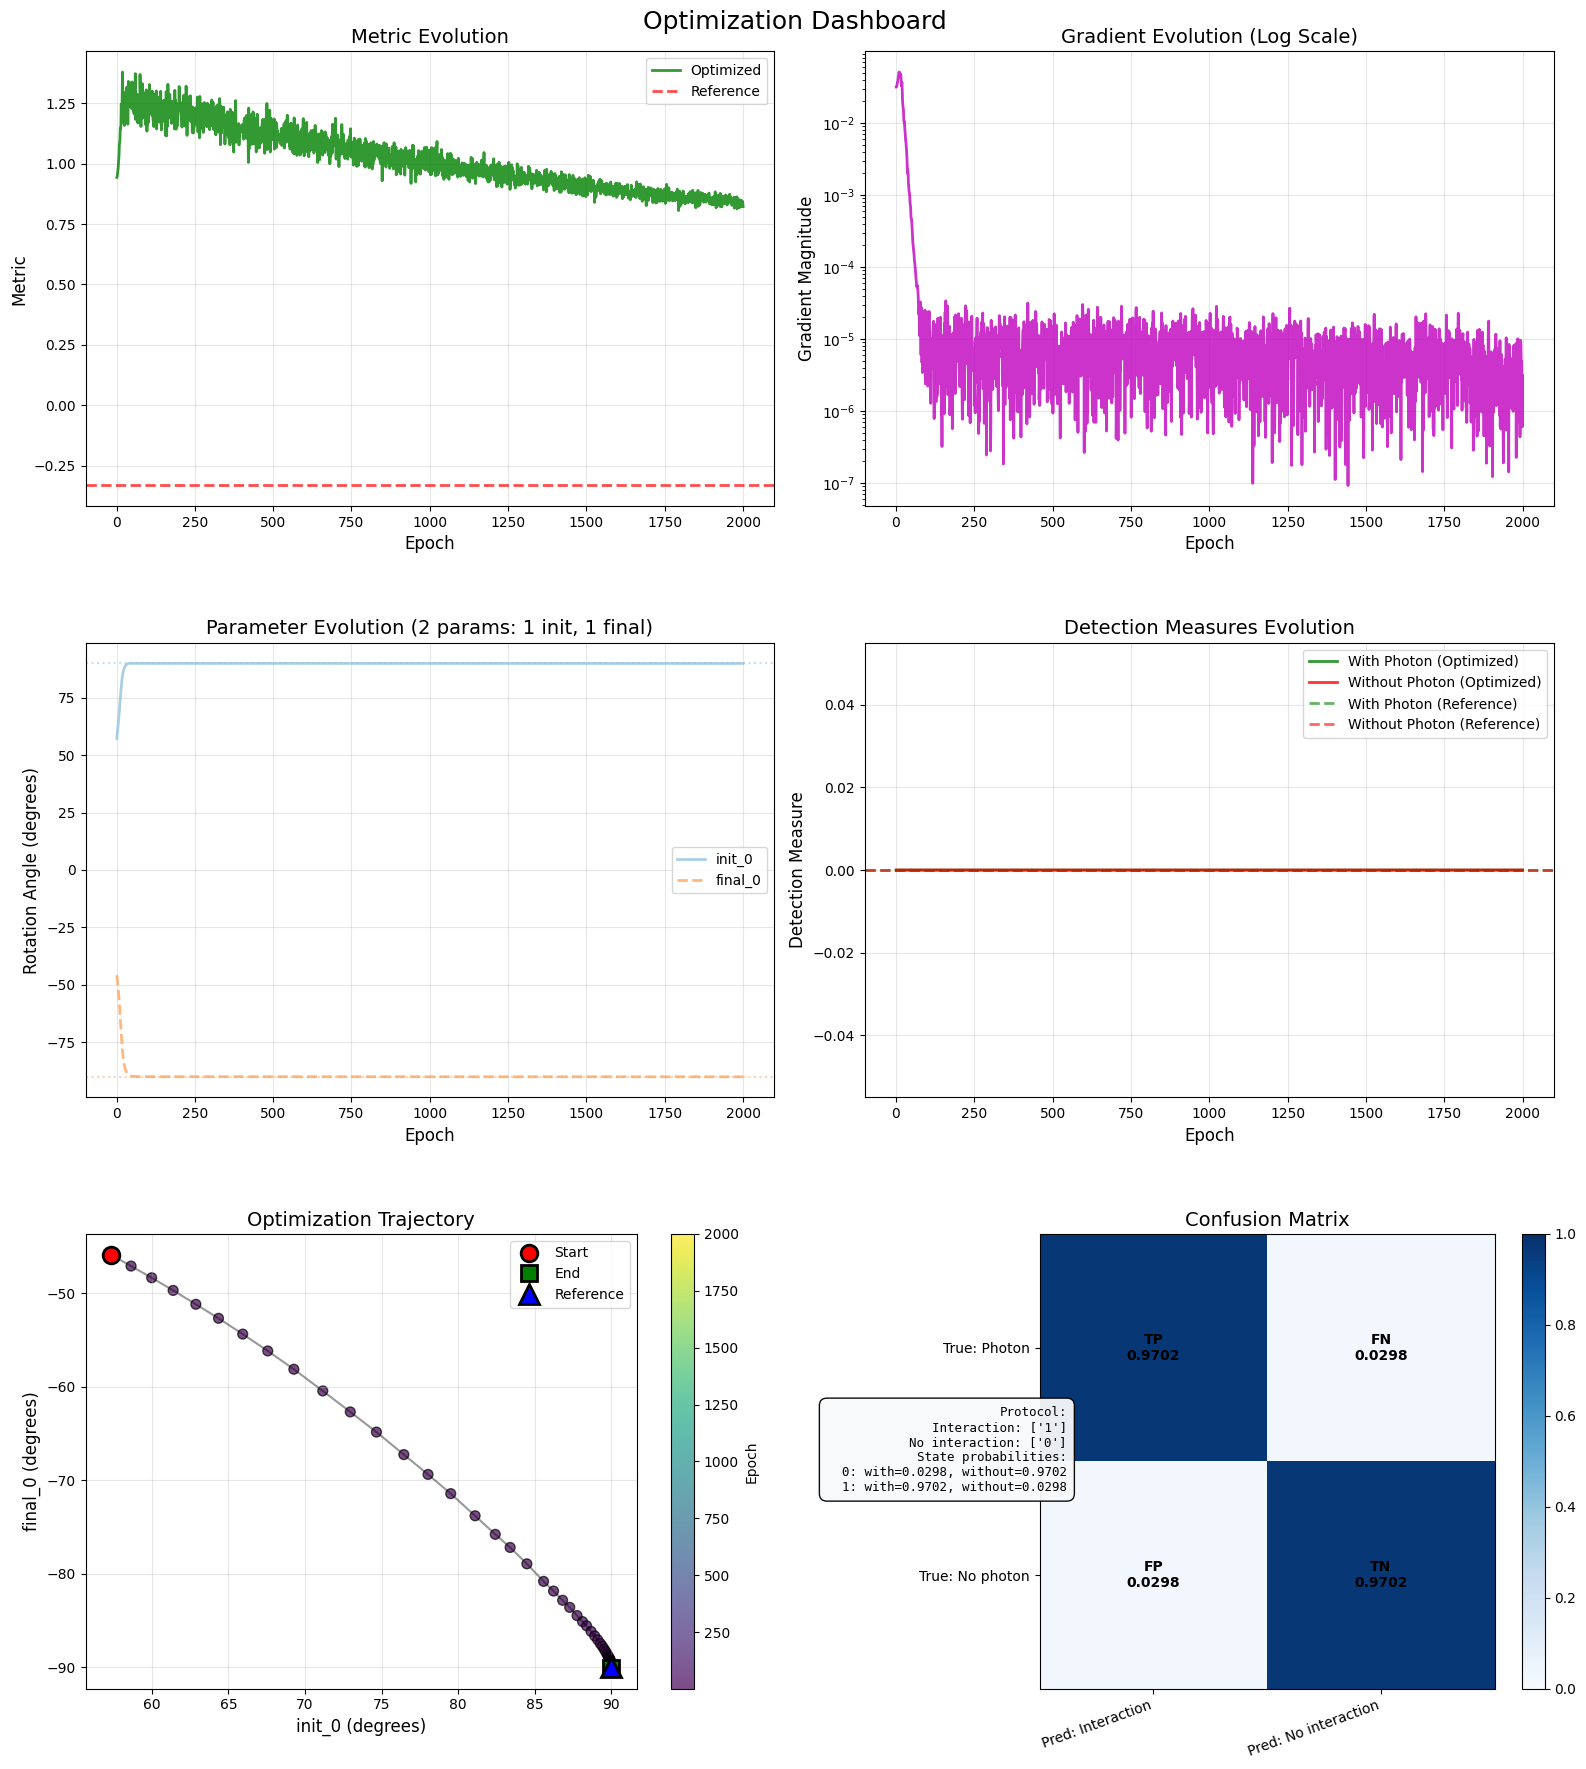

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    show_confusion_matrix_summary=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [ ]:
# time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

In [ ]:
# from qsopt.utils.visualization import plot_time_interval_landscape

# fig = plot_time_interval_landscape(
#     landscape_data=time_callback,
#     exp_params=experiment.experimental_params,
#     save_path='results/time_interval_opt.pdf'
# )


## Sweep chi-gamma

In [ ]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 30.00] (linear scale)
  γ range: [1.00, 60.00] (linear scale)


  Progress: 10.0% | Elapsed: 61.5s
  Progress: 20.0% | Elapsed: 120.9s


KeyboardInterrupt: 

SweepResults:
  Parameter 1: gamma
    Interval: [1, 60]
    Scale: linear
    Resolution: 10 points
  Parameter 2: chi
    Interval: [1, 30]
    Scale: linear
    Resolution: 10 points
  Available results: detection_map, detection_without_map, metric_map
  Optimal point: chi=17.1, gamma=40.3


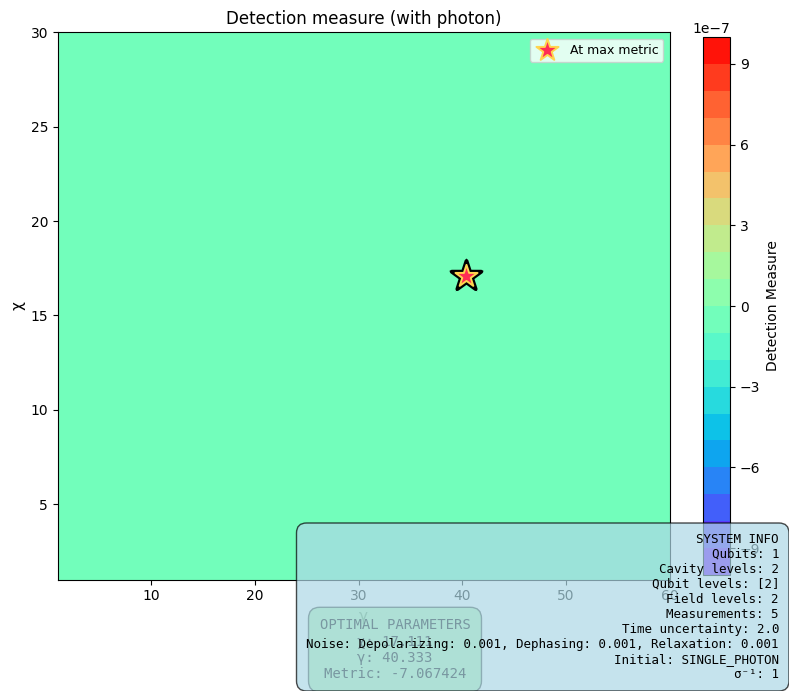

In [ ]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()

## Continue Optimization From a Saved Callback

You can stop and resume optimization by saving the callback to disk and loading it back with `OptimizationCallback.load_callback`.
This restores both parameters and optimizer state (and gradients), so `hot_start=True` continues from the saved point.

In [ ]:
history.save('results/single_qubit_hotstart.npz')

loaded_history = OptimizationCallback.load_callback('results/single_qubit_hotstart.npz')

history_resumed = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    verbose=True,
    verbose_step=1,
    tolerance=1e-7,
    callback=loaded_history,
    optimizer=optax.sgd(learning_rate=0.5),
    hot_start=True,
)

print(history_resumed)

print('\n' + '-' * 80 + '\n')

# Build a fresh experiment for a clean 15-step baseline from the same initial values
baseline_experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=create_ry_circuit(n_qubits=1, theta_values=[np.pi / 2]),
    final_circuit=create_ry_circuit(n_qubits=1, theta_values=[-np.pi / 2]),
    detection_metric=detection_metric,
 )

continued_callback = OptimizationCallback(save_every=1, save_best=True)
history_continued = baseline_experiment.optimize_rotations(
    initial_values=[1.3, -1.0], 
    num_steps=15,
    verbose=True,
    verbose_step=1,
    batch_size=1,
    tolerance=1e-7,
    callback=continued_callback,
    optimizer=optax.sgd(learning_rate=0.5)
)

print(history_continued)

m_resumed = np.array(history_resumed.history['metric'], dtype=float)
m_continued = np.array(history_continued.history['metric'], dtype=float)
n_overlap = min(len(m_resumed), len(m_continued))
print(f'len(resumed)={len(m_resumed)}, len(continued)={len(m_continued)}')
print('max_abs_metric_diff_on_overlap=', float(np.max(np.abs(m_resumed[:n_overlap] - m_continued[:n_overlap]))))

Starting hot start optimization, trying to load last parameters, optimizer state, and gradients from callback:
- Parameters LOADED
- Gradients LOADED
- Optimizer state LOADED
Resuming from epoch 500, running until epoch 510
Configuration:
    Max iterations: 510
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection metric:
maximize computational distance with custom metric
    Trainable parameters: 3 (2 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 0.425  rad (24.4°)
        param1.  setup_RZ[0]  = -0.145 rad (-8.3°)
        param2.  reset_RY[0]  = -2.719 rad (-155.8°)
    Measurement uncertainty: ±2.000
Step  setup0_RY[0]   setup1_RZ[0]   reset0_RY[0]   Metric      Validation  Grad Norm   Time
------------------------------------------------------------------------------------------------


/raid/home/ncampioni/Quantum-sensing-QML/src/qsopt/core/experiment/experiment.py:1421: UserWarning: Using a small batch size of 1 for optimization with measurement uncertainty may lead to noisy gradients and slow convergence. Consider increasing the batch size for better performance.
  warnings.warn(f"Using a small batch size of {batch_size} for optimization with measurement uncertainty may lead to noisy gradients and slow convergence. Consider increasing the batch size for better performance.")


500   0.425180       -0.144790      -2.719415      -17.359936  -18.065797  2.96e+01    00h00m36s
501   10.865092      0.192956       7.733137       -13.751098  -14.297670  9.93e+00    00h00m37s
502   7.718702       2.443521       4.624493       -10.380891  -10.776870  8.55e+00    00h00m37s
503   7.849031       -1.746302      5.466570       -7.778830   -8.000014   1.27e+00    00h00m37s
504   7.215076       -1.747654      5.476627       -9.872603   -10.110722  1.04e+01    00h00m37s
505   10.938705      -3.770112      2.425409       -8.838928   -9.035172   9.25e+00    00h00m37s
506   6.891052       -4.953590      4.329354       -8.709930   -8.849660   7.11e+00    00h00m37s
507   8.177850       -6.211151      7.398027       -29.575093  -29.926161  1.15e+01    00h00m37s
508   4.183769       -4.485889      3.636147       -12.951079  -13.053257  1.72e+01    00h00m38s
509   11.661441      -8.680673      4.358974       -9.677815   -9.715879   1.29e+01    00h00m38s
Final gradient norm: 1.29e+01


KeyboardInterrupt: 

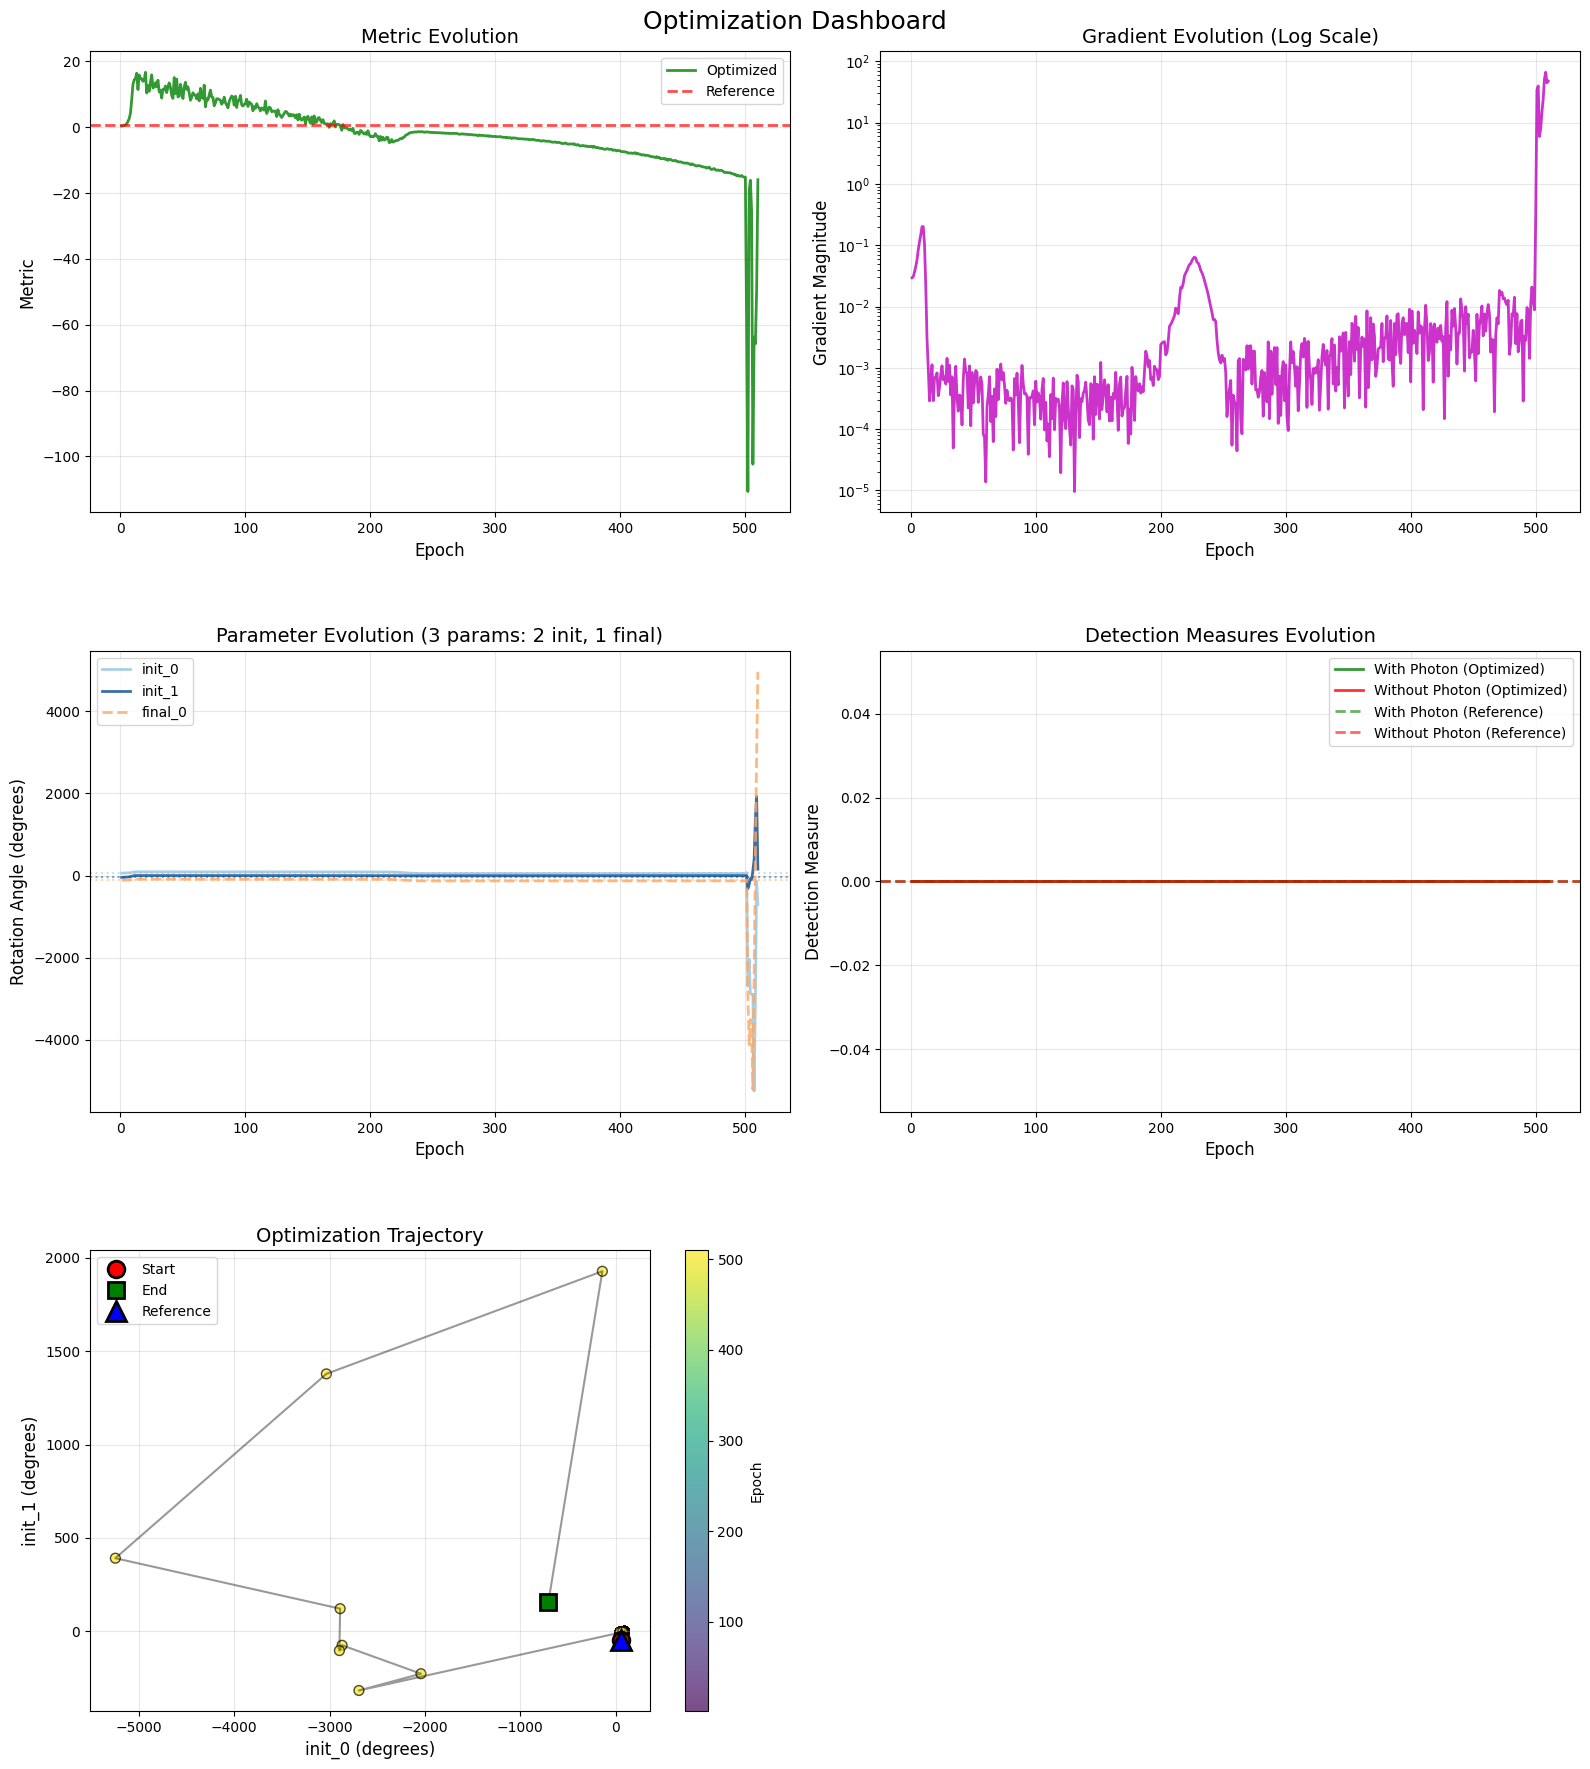

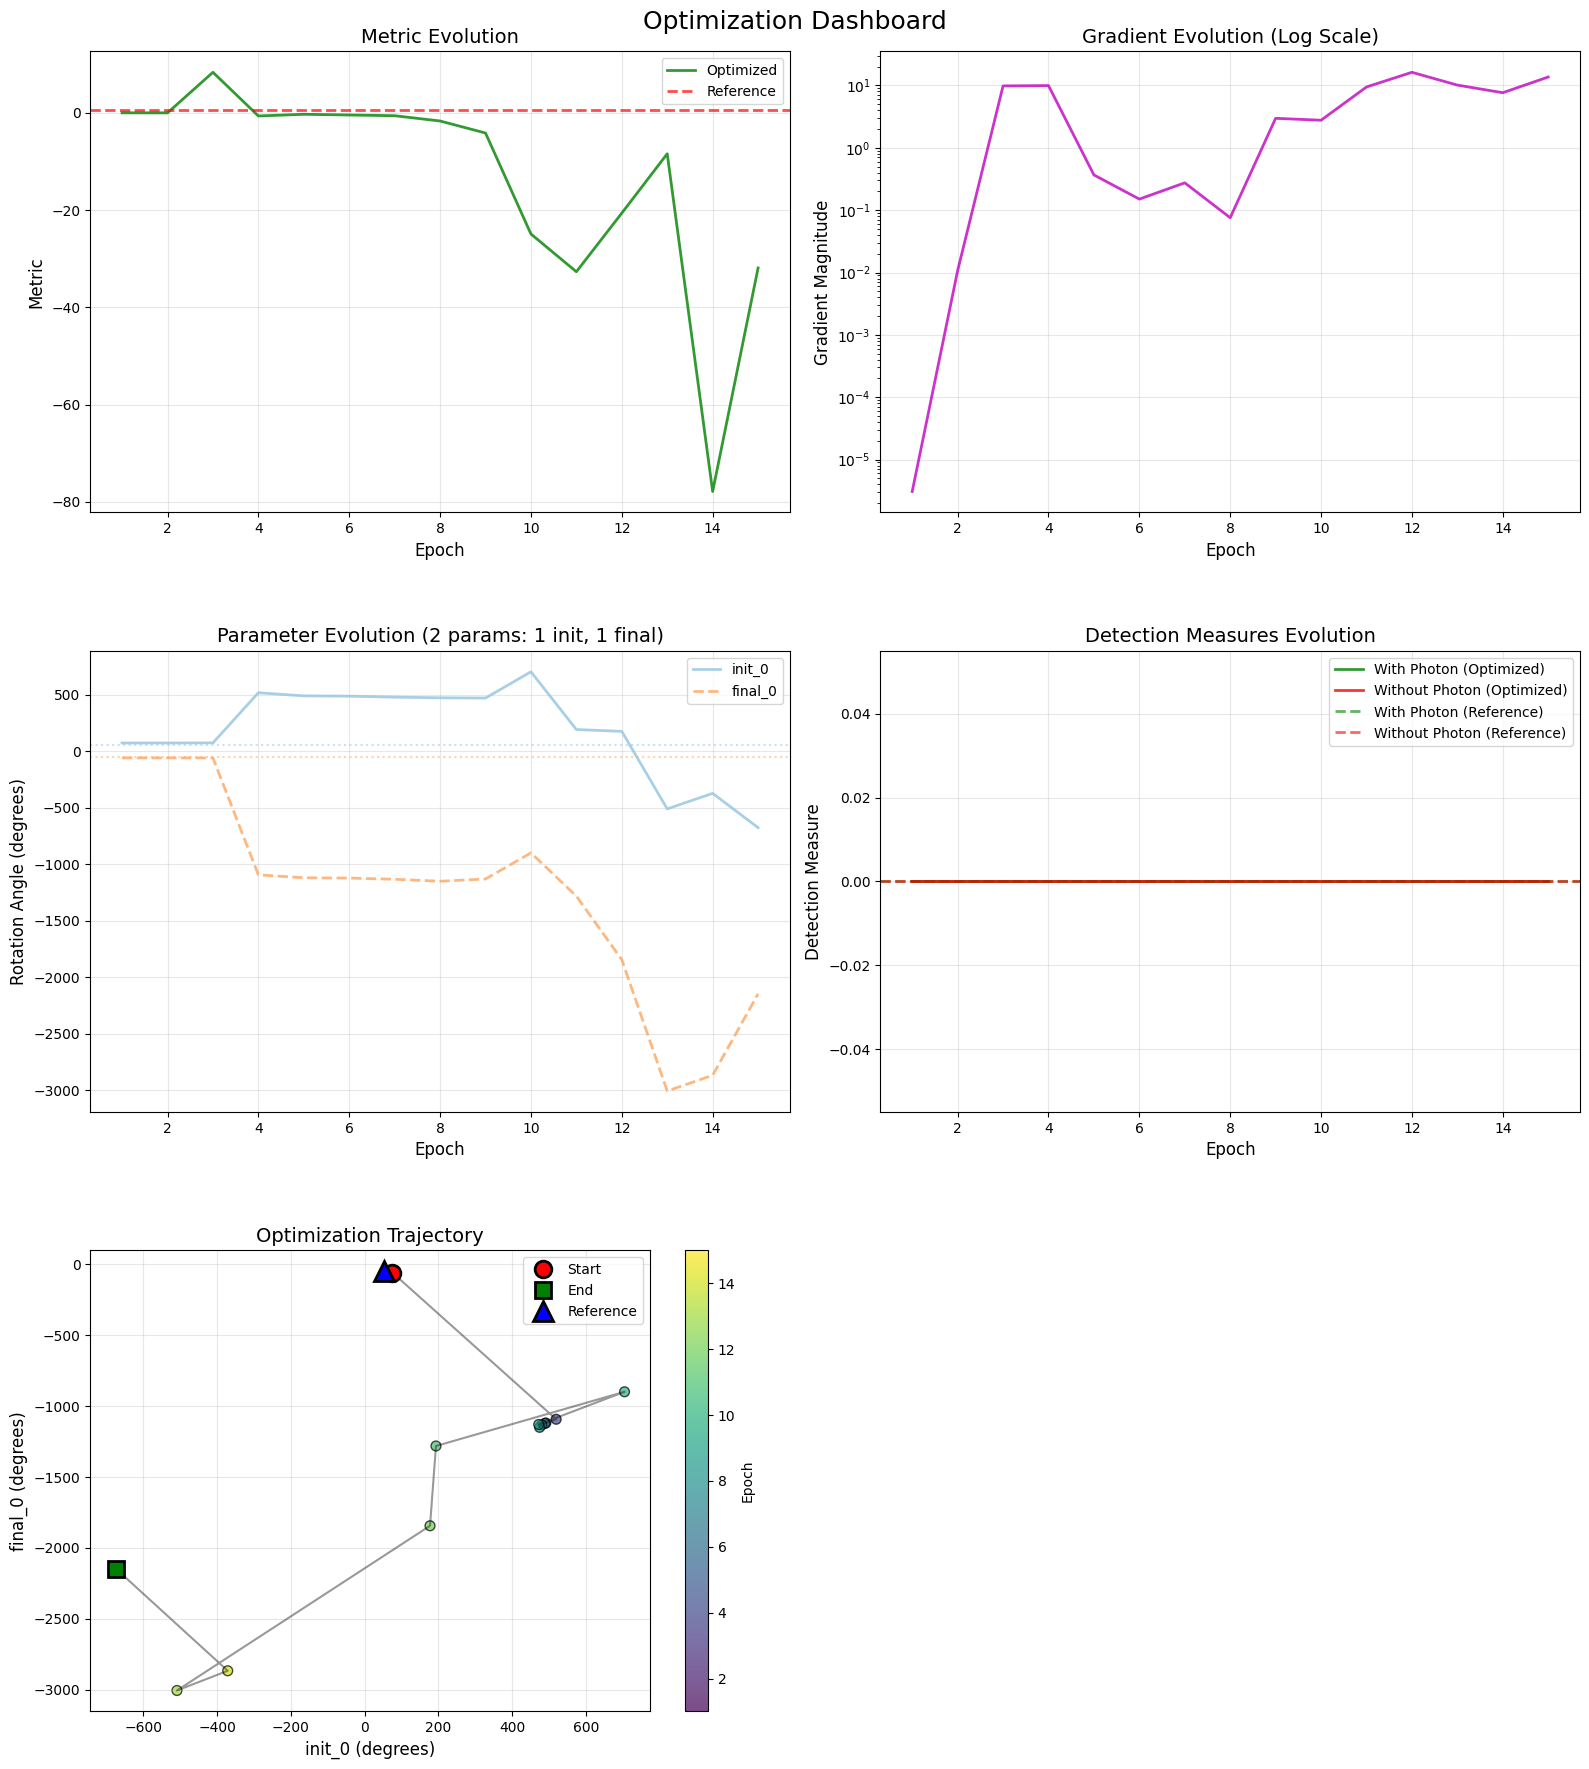

In [ ]:
# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_resumed,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history_continued,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard_resumed.pdf'  # Save to file
)

plt.show()

In [ ]:
import numpy as np

res_epochs = np.array(history_resumed.history.get('epochs', []), dtype=int)
res_metric = np.array(history_resumed.history.get('metric', []), dtype=float)

cont_epochs = np.array(history_continued.history.get('epochs', []), dtype=int)
cont_metric = np.array(history_continued.history.get('metric', []), dtype=float)

print('resumed_epochs:', res_epochs.tolist())
print('resumed_metric:', res_metric.tolist())
print('continued_epochs:', cont_epochs.tolist())
print('continued_metric:', cont_metric.tolist())

n = min(len(res_metric), len(cont_metric))
print('overlap_len:', n)
if n > 0:
    diffs = np.abs(res_metric[:n] - cont_metric[:n])
    print('overlap_abs_diff:', diffs.tolist())
    print('max_abs_diff_overlap:', float(np.max(diffs)))

print('history_epochs:', history.history.get('epochs', []))
print('history_metric:', history.history.get('metric', []))

resumed_epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 2